# Does `Counter` beat a Python counting loop?

The claim: `collections.Counter(data)` should be faster than counting with a Python `for` loop, because the inner loop runs in C (`_count_elements` in `_collectionsmodule.c`) and skips per-element **bytecode dispatch**.

A list-increment loop (`counts[x] += 1`) still pays for a Python iterator, `BINARY_SUBSCR`, and `INPLACE_ADD` on every item.

That comparison mixes two effects: **C vs bytecode**, and **hash table vs array index**. So we time three implementations on the same data:

- **`Counter(data)`** — C loop + dict
- **manual dict** — Python loop + dict (same structure as Counter; isolates bytecode)
- **manual list** — Python loop + `counts[x] += 1` (the “create a list manually” version)

What would falsify the claim:

- **Dict vs Counter:** Counter should be clearly faster, and the gap should grow with `n`. If not, the C-loop story is wrong on this CPython.
- **List vs Counter:** the list may win at small `n` (no hashing). If it still wins at large `n`, bytecode is not the whole story — indexing vs hashing is.

In [1]:
from collections import Counter
import dis
import random
import timeit

import matplotlib.pyplot as plt

K = 100


def count_list(data, k=K):
    counts = [0] * k
    for x in data:
        counts[x] += 1
    return counts


def count_dict(data):
    counts = {}
    for x in data:
        counts[x] = counts.get(x, 0) + 1
    return counts


def count_counter(data):
    return Counter(data)

## Bytecode: where the loop lives

`dis.dis` shows the Python bytecode the evaluator actually runs. The list and dict versions contain an explicit `FOR_ITER` loop. `count_counter` is a single `CALL` into C — no Python-level iteration.

In [2]:
print("=== count_list ===")
dis.dis(count_list)

=== count_list ===
 11           0 RESUME                   0

 12           2 LOAD_CONST               1 (0)
              4 BUILD_LIST               1
              6 LOAD_FAST                1 (k)
              8 BINARY_OP                5 (*)
             12 STORE_FAST               2 (counts)

 13          14 LOAD_FAST                0 (data)
             16 GET_ITER
        >>   18 FOR_ITER                15 (to 52)
             22 STORE_FAST               3 (x)

 14          24 LOAD_FAST                2 (counts)
             26 LOAD_FAST                3 (x)
             28 COPY                     2
             30 COPY                     2
             32 BINARY_SUBSCR
             36 LOAD_CONST               2 (1)
             38 BINARY_OP               13 (+=)
             42 SWAP                     3
             44 SWAP                     2
             46 STORE_SUBSCR
             50 JUMP_BACKWARD           17 (to 18)

 13     >>   52 END_FOR

 15          54 LOAD_FAS

In [3]:
print("=== count_dict ===")
dis.dis(count_dict)

=== count_dict ===
 18           0 RESUME                   0

 19           2 BUILD_MAP                0
              4 STORE_FAST               1 (counts)

 20           6 LOAD_FAST                0 (data)
              8 GET_ITER
        >>   10 FOR_ITER                26 (to 66)
             14 STORE_FAST               2 (x)

 21          16 LOAD_FAST                1 (counts)
             18 LOAD_ATTR                1 (NULL|self + get)
             38 LOAD_FAST                2 (x)
             40 LOAD_CONST               1 (0)
             42 CALL                     2
             50 LOAD_CONST               2 (1)
             52 BINARY_OP                0 (+)
             56 LOAD_FAST                1 (counts)
             58 LOAD_FAST                2 (x)
             60 STORE_SUBSCR
             64 JUMP_BACKWARD           28 (to 10)

 20     >>   66 END_FOR

 22          68 LOAD_FAST                1 (counts)
             70 RETURN_VALUE


In [4]:
print("=== count_counter ===")
dis.dis(count_counter)
print("Counter.__init__ is implemented in C:", type(Counter.__init__))

=== count_counter ===
 25           0 RESUME                   0

 26           2 LOAD_GLOBAL              1 (NULL + Counter)
             12 LOAD_FAST                0 (data)
             14 CALL                     1
             22 RETURN_VALUE
Counter.__init__ is implemented in C: <class 'function'>


## Correctness

Same frequencies on a small input, so later timings compare equivalent work.

In [5]:
sample = [3, 1, 3, 0, 1, 1]
list_counts = count_list(sample)
dict_counts = count_dict(sample)
counter_counts = count_counter(sample)

assert all(list_counts[i] == dict_counts.get(i, 0) == counter_counts[i] for i in range(K))
print("list :", [c for c in list_counts if c][:10], "(nonzero entries)")
print("dict :", dict(sorted(dict_counts.items())))
print("counter:", dict(sorted(counter_counts.items())))

list : [1, 3, 2] (nonzero entries)
dict : {0: 1, 1: 3, 3: 2}
counter: {0: 1, 1: 3, 3: 2}


## Timing sweep

Random ints in `0 .. 99` (`K = 100`) so a dense list is valid. Input is generated **once per `n`** and is not part of the timed region.

`n` is log-spaced from $10^3$ to $10^6$. `timeit.Timer.repeat` with `autorange`; we report the **minimum** seconds per call (standard microbench practice — less noise from GC / interrupts).

In [6]:
SIZES = [10**3, 3 * 10**3, 10**4, 3 * 10**4, 10**5, 3 * 10**5, 10**6]
FNS = {
    "Counter": count_counter,
    "manual dict": count_dict,
    "manual list": count_list,
}

rng = random.Random(0)
results = {name: [] for name in FNS}


def bench(fn, data):
    timer = timeit.Timer(lambda: fn(data))
    number, _ = timer.autorange()
    times = timer.repeat(repeat=5, number=number)
    return min(times) / number


for n in SIZES:
    data = [rng.randrange(K) for _ in range(n)]
    for name, fn in FNS.items():
        results[name].append(bench(fn, data))
    print(
        f"n={n:>8,}:  "
        + "  ".join(f"{name}={results[name][-1]*1e3:7.3f} ms" for name in FNS)
    )

n=   1,000:  Counter=  0.018 ms  manual dict=  0.029 ms  manual list=  0.016 ms


n=   3,000:  Counter=  0.049 ms  manual dict=  0.080 ms  manual list=  0.047 ms


n=  10,000:  Counter=  0.162 ms  manual dict=  0.261 ms  manual list=  0.155 ms


n=  30,000:  Counter=  0.517 ms  manual dict=  0.845 ms  manual list=  0.522 ms


n= 100,000:  Counter=  2.158 ms  manual dict=  3.192 ms  manual list=  2.194 ms


n= 300,000:  Counter=  6.812 ms  manual dict=  9.972 ms  manual list=  6.595 ms


n=1,000,000:  Counter= 23.071 ms  manual dict= 34.062 ms  manual list= 22.321 ms


In [7]:
print(f"{'n':>10}  {'Counter (ms)':>14}  {'dict (ms)':>12}  {'list (ms)':>12}  {'dict/Counter':>12}  {'list/Counter':>12}")
print("-" * 80)
for i, n in enumerate(SIZES):
    c, d, lst = results["Counter"][i], results["manual dict"][i], results["manual list"][i]
    print(
        f"{n:>10,}  {c*1e3:14.3f}  {d*1e3:12.3f}  {lst*1e3:12.3f}  {d/c:12.2f}x  {lst/c:12.2f}x"
    )

         n    Counter (ms)     dict (ms)     list (ms)  dict/Counter  list/Counter
--------------------------------------------------------------------------------
     1,000           0.018         0.029         0.016          1.61x          0.89x
     3,000           0.049         0.080         0.047          1.62x          0.95x
    10,000           0.162         0.261         0.155          1.62x          0.96x
    30,000           0.517         0.845         0.522          1.64x          1.01x
   100,000           2.158         3.192         2.194          1.48x          1.02x
   300,000           6.812         9.972         6.595          1.46x          0.97x
 1,000,000          23.071        34.062        22.321          1.48x          0.97x


## Plots

Log–log time vs `n` keeps constant-factor gaps visible as size grows. Nanoseconds per element should be roughly flat if per-item dispatch (or hashing) dominates.

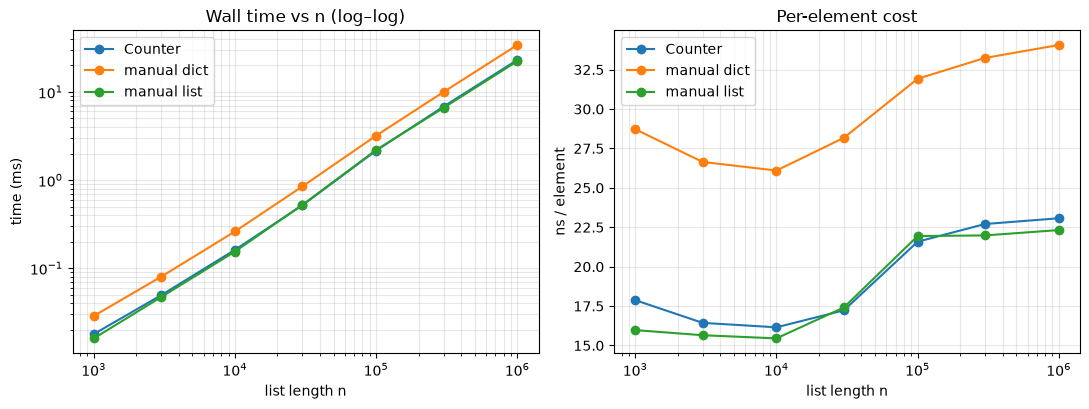

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for name, times in results.items():
    axes[0].plot(SIZES, [t * 1e3 for t in times], marker="o", label=name)
    axes[1].plot(SIZES, [t / n * 1e9 for t, n in zip(times, SIZES)], marker="o", label=name)

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("list length n")
axes[0].set_ylabel("time (ms)")
axes[0].set_title("Wall time vs n (log–log)")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)

axes[1].set_xscale("log")
axes[1].set_xlabel("list length n")
axes[1].set_ylabel("ns / element")
axes[1].set_title("Per-element cost")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

fig.tight_layout()
plt.show()

## How to read the result

- **`manual dict` vs `Counter`** is the fair bytecode test: same hash-table work, Python loop vs C loop. If Counter is faster by a roughly constant factor, that factor *is* bytecode dispatch (plus the extra `dict.get` call in the Python version).
- **`manual list` vs `Counter`** adds a second axis: `list[int]` increment is a pointer write, not a hash. A faster list does **not** refute the C-loop claim — it says indexing beat hashing even after paying for bytecode.
- Per-element ns flattening at large `n` means setup (`[0]*K`, allocating the `Counter`) has amortized away, and we are seeing the loop itself.